In [1]:
data <- read.csv("IBM.csv")

In [2]:
head(data)

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
,<int>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>
1,41,Yes,Sales,1,2,Life Sciences,2,4,Single,5993,8,1,6
2,49,No,Research & Development,8,1,Life Sciences,3,2,Married,5130,1,3,10
3,37,Yes,Research & Development,2,2,Other,4,3,Single,2090,6,3,0
4,33,No,Research & Development,3,4,Life Sciences,4,3,Married,2909,1,3,8
5,27,No,Research & Development,2,1,Medical,1,2,Married,3468,9,3,2
6,32,No,Research & Development,2,2,Life Sciences,4,4,Single,3068,0,2,7


In [3]:
dim(data)

[1] 1470   13

In [4]:
names(data)

[1] "Age"                     "Attrition"              
 [3] "Department"              "DistanceFromHome"       
 [5] "Education"               "EducationField"         
 [7] "EnvironmentSatisfaction" "JobSatisfaction"        
 [9] "MaritalStatus"           "MonthlyIncome"          
[11] "NumCompaniesWorked"      "WorkLifeBalance"        
[13] "YearsAtCompany"

In [5]:
summary(data)

      Age            Attrition        Department   DistanceFromHome
 Min.   :18.00   Length   :1470   Length   :1470   Min.   : 1.000  
 1st Qu.:30.00   N.unique :   2   N.unique :   3   1st Qu.: 2.000  
 Median :36.00   N.blank  :   0   N.blank  :   0   Median : 7.000  
 Mean   :36.92   Min.nchar:   2   Min.nchar:   5   Mean   : 9.193  
 3rd Qu.:43.00   Max.nchar:   3   Max.nchar:  22   3rd Qu.:14.000  
 Max.   :60.00                                     Max.   :29.000  
   Education       EducationField EnvironmentSatisfaction JobSatisfaction
 Min.   :1.000   Length   :1470   Min.   :1.000           Min.   :1.000  
 1st Qu.:2.000   N.unique :   6   1st Qu.:2.000           1st Qu.:2.000  
 Median :3.000   N.blank  :   0   Median :3.000           Median :3.000  
 Mean   :2.913   Min.nchar:   5   Mean   :2.722           Mean   :2.729  
 3rd Qu.:4.000   Max.nchar:  16   3rd Qu.:4.000           3rd Qu.:4.000  
 Max.   :5.000                    Max.   :4.000           Max.   :4.000  
   Mar

In [6]:
colSums(is.na(data))

Age               Attrition              Department 
                      0                       0                       0 
       DistanceFromHome               Education          EducationField 
                      0                       0                       0 
EnvironmentSatisfaction         JobSatisfaction           MaritalStatus 
                      0                       0                       0 
          MonthlyIncome      NumCompaniesWorked         WorkLifeBalance 
                      0                       0                       0 
         YearsAtCompany 
                      0

In [7]:
data$Age[is.na(data$Age)] <- mean(data$Age, na.rm = TRUE)

data$MonthlyIncome[is.na(data$MonthlyIncome)] <-
  mean(data$MonthlyIncome, na.rm = TRUE)

In [8]:
data <- unique(data)

In [11]:
install.packages("ggplot2")
install.packages("corrplot")
install.packages("dplyr")

Warning message:
"package 'ggplot2' is in use and will not be installed"
Warning message:
"package 'corrplot' is in use and will not be installed"
Warning message:
"package 'dplyr' is in use and will not be installed"


In [13]:
library(ggplot2)
library(corrplot)
library(dplyr)

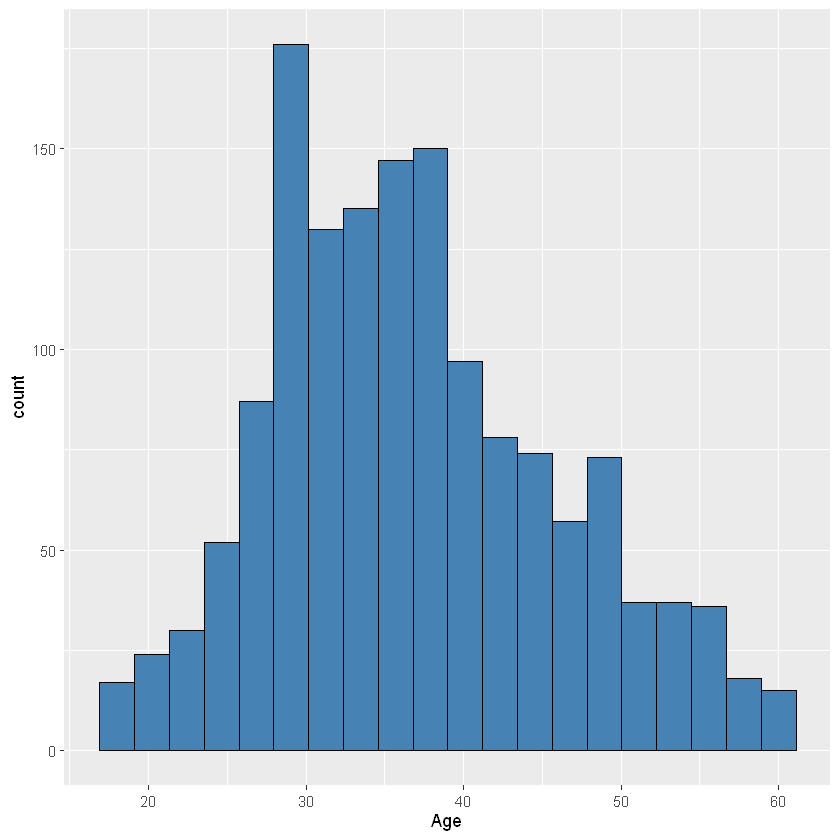

In [14]:
ggplot(data, aes(Age)) +
  geom_histogram(fill="steelblue", color="black", bins=20)

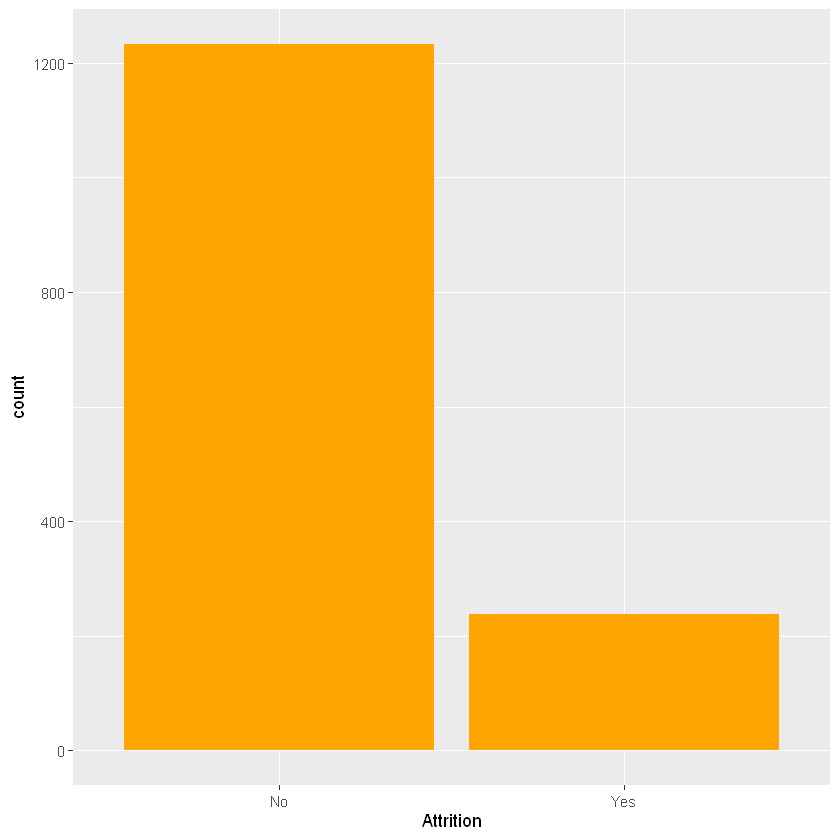

In [15]:
ggplot(data, aes(Attrition)) +
  geom_bar(fill="orange")

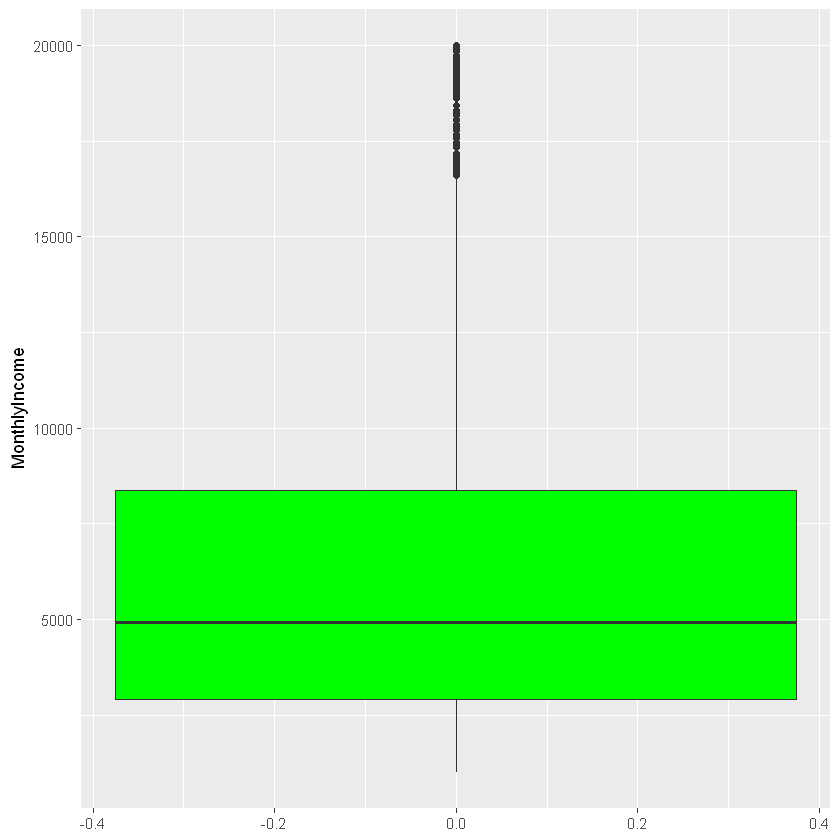

In [16]:
ggplot(data, aes(y=MonthlyIncome)) +
  geom_boxplot(fill="green")

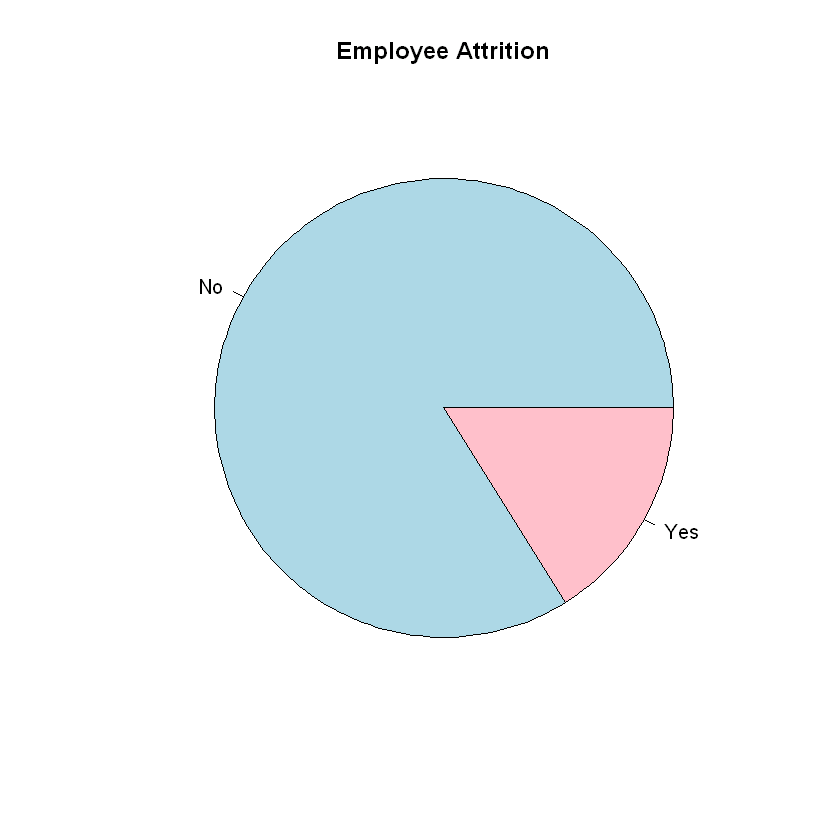

In [17]:
pie(table(data$Attrition),
    col=c("lightblue","pink"),
    main="Employee Attrition")

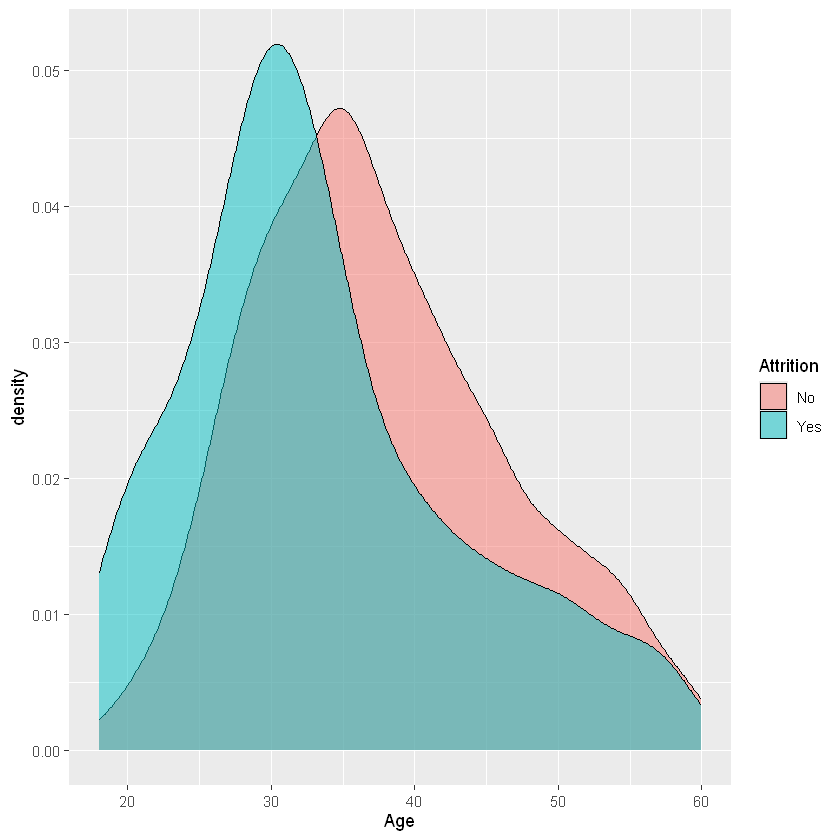

In [18]:
ggplot(data, aes(Age, fill=Attrition))+
geom_density(alpha=0.5)

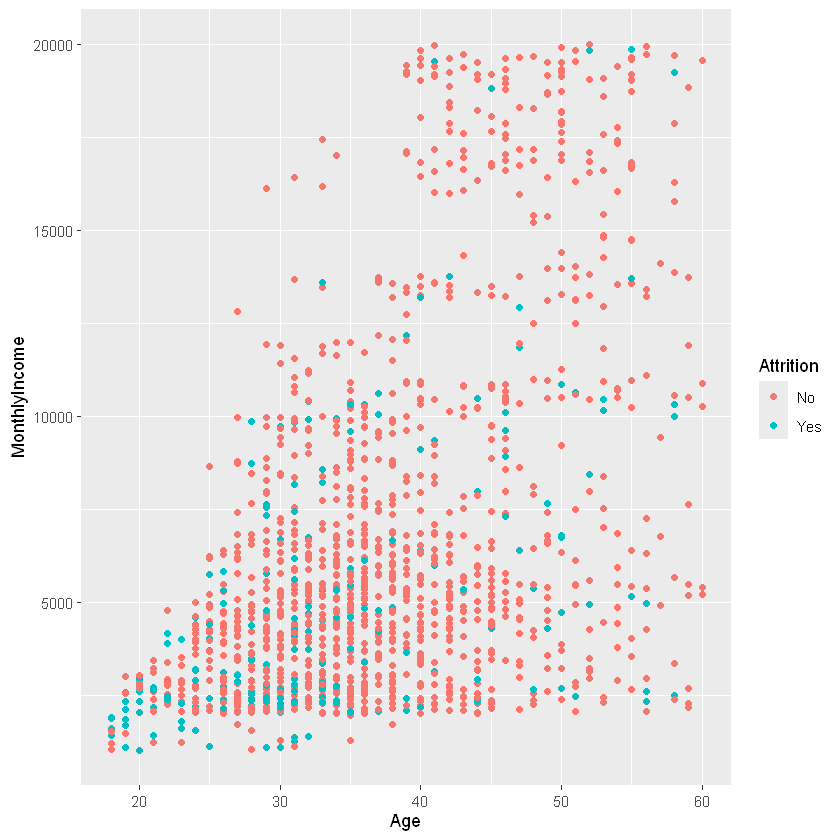

In [19]:
ggplot(data,
aes(Age, MonthlyIncome,
color=Attrition))+
geom_point()

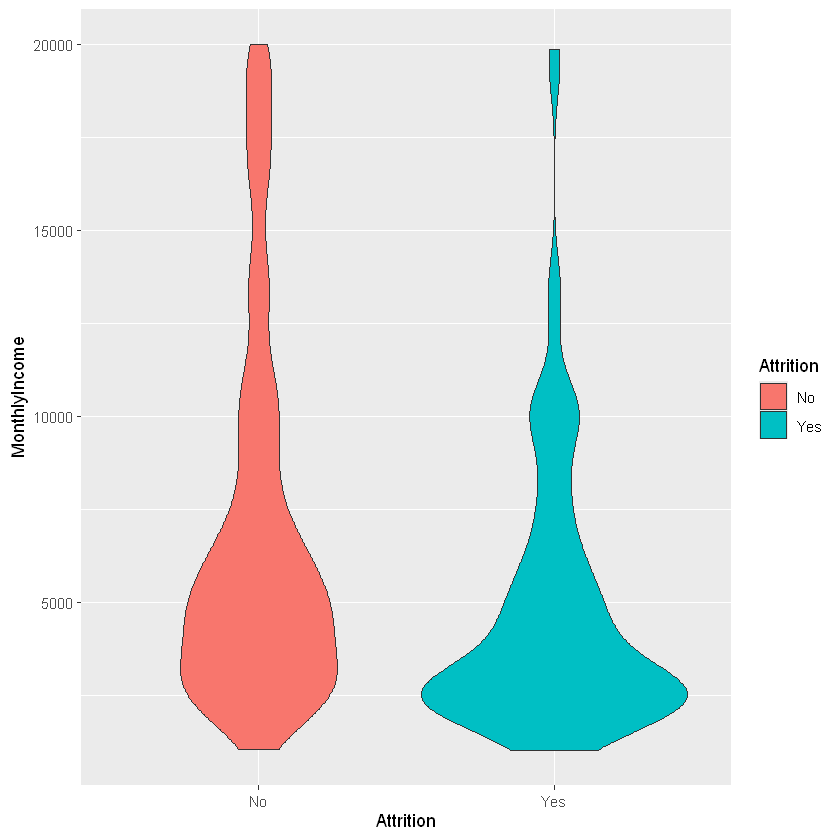

In [20]:
ggplot(data,
aes(Attrition, MonthlyIncome,
fill=Attrition))+
geom_violin()

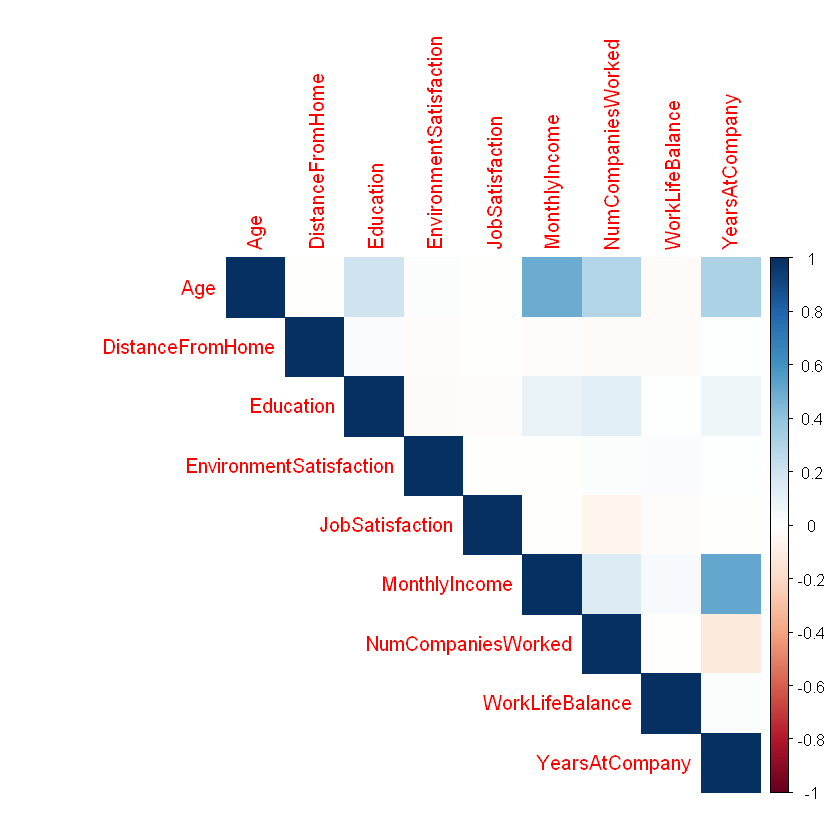

In [21]:
numeric_data <- data[sapply(data,is.numeric)]

cor_matrix <- cor(numeric_data)

corrplot(cor_matrix,
method="color",
type="upper")

In [26]:
model <- glm(Attrition~.,
data=train,
family="binomial")

summary(model)


Call:
glm(formula = Attrition ~ ., family = "binomial", data = train)

Coefficients:
                                   Estimate Std. Error z value Pr(>|z|)    
(Intercept)                       2.078e+00  8.298e-01   2.504 0.012286 *  
Age                              -2.894e-02  1.175e-02  -2.464 0.013757 *  
DepartmentResearch & Development -7.401e-02  5.738e-01  -0.129 0.897363    
DepartmentSales                   4.957e-01  5.947e-01   0.834 0.404499    
DistanceFromHome                  2.796e-02  1.013e-02   2.761 0.005770 ** 
Education                        -3.147e-02  8.716e-02  -0.361 0.718012    
EducationFieldLife Sciences      -7.324e-01  7.936e-01  -0.923 0.356054    
EducationFieldMarketing          -5.178e-01  8.417e-01  -0.615 0.538373    
EducationFieldMedical            -1.044e+00  7.946e-01  -1.314 0.188944    
EducationFieldOther              -1.108e+00  8.622e-01  -1.285 0.198918    
EducationFieldTechnical Degree   -3.535e-01  8.169e-01  -0.433 0.665246    
En

In [27]:
pred <- predict(model,
test,
type="response")

pred <- ifelse(pred>0.5,"Yes","No")

In [28]:
table(Predicted=pred,
Actual=test$Attrition)

         Actual
Predicted  No Yes
      No  246  41
      Yes   1   6

In [29]:
mean(pred==test$Attrition)

[1] 0.8571429